#Latent Semantic Analysis

Latent Semantic Analysis (LSA) is a technique used to find hidden relationships and meanings in text data. It analyzes how words appear in different documents and helps computers understand the context of words instead of only matching exact words.

- Converts text into a document-term matrix.
- Uses mathematical methods to reduce unnecessary data.
- Finds relationships between similar words and documents.
- Helps in search engines and text analysis tasks.

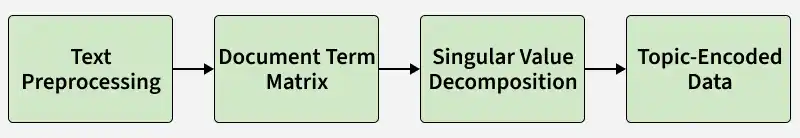

**Example 1: Topic Modeling (Discovering Hidden Themes)**

In this example, we take a small collection of text and use LSA to uncover the "latent" topics. LSA will group related words together into concepts.

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [ ]:

# 1. Sample Dataset (Documents about space, cats, and computer science)
documents = [
    "The celestial stars and galaxies illuminate the deep space night sky.",
    "Data structures and algorithms are fundamental to computer science.",
    "Cats are cute feline animals that love to chase mice and sleep.",
    "NASA sent a rover to explore the surface of Mars and look for water.",
    "Python is a popular programming language for software development.",
    "A kitten is a young cat that needs plenty of care and affection."
]

# 2. Convert text to a TF-IDF matrix
# (LSA works best with TF-IDF because it downweights overly common words like "the")
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)

In [ ]:
# 3. Apply LSA via TruncatedSVD
# We want to compress our vocabulary down to 3 main topics/concepts
num_topics = 4 # Increased from 3 to allow for more granular topic separation
lsa_model = TruncatedSVD(n_components=num_topics, random_state=42)
lsa_matrix = lsa_model.fit_transform(tfidf_matrix)

In [ ]:
# 4. Extract and display the top words for each topic
terms = vectorizer.get_feature_names_out()

In [ ]:
print("--- DISCOVERED TOPICS ---")
for i, comp in enumerate(lsa_model.components_):
    # Sort the words by their importance in this specific topic
    terms_comp = zip(terms, comp)
    sorted_terms = sorted(terms_comp, key=lambda x: x[1], reverse=True)[:3]

    topic_words = ", ".join([t[0] for t in sorted_terms])
    print(f"Topic {i+1}: {topic_words}")

--- DISCOVERED TOPICS ---
Topic 1: algorithms, computer, data
Topic 2: explore, look, mars
Topic 3: development, language, popular
Topic 4: cat, care, kitten


TfidfVectorizer turns the text into a mathematical grid of word frequencies.

TruncatedSVD is the engine of LSA. It reduces the massive dimensionality of all the words down to just 3 "concepts".

If you run this, you'll see it successfully clusters words like (cats, kitten, feline), (space, stars, nasa), and (programming, computer, science) together.

**Example 2: Semantic Document Similarity**

Standard keyword matching fails if two sentences mean the same thing but use different words. LSA fixes this by mapping documents into a "semantic space" where synonyms sit close to each other.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# 1. A dataset of sentences + a new query we want to match
corpus = [
    "Doctors perform surgery in the hospital operating room.",
    "The stock market saw a massive crash today.",
    "Physicians conduct medical procedures on patients."
]

query = ["Medical professionals are working in the clinic."]

In [ ]:
# 2. Vectorize the entire text pool (Corpus + Query) together
vectorizer = TfidfVectorizer(stop_words='english')

all_docs = corpus + query

tfidf_matrix = vectorizer.fit_transform(all_docs)

In [ ]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (4, 20)>

In [ ]:
# 3. Apply LSA to capture synonyms/concepts
# We'll reduce it to 2 dimensions for simplicity
lsa = TruncatedSVD(n_components=2, random_state=42)

lsa_matrix = lsa.fit_transform(tfidf_matrix)

In [ ]:
lsa_matrix

array([[ 5.19788915e-17,  1.00000000e+00],
       [-4.07181777e-15, -4.51509455e-19],
       [ 7.58925506e-01, -2.32566622e-17],
       [ 7.58925506e-01,  5.91020220e-17]])

In [ ]:
# Separate the processed corpus from the processed query
corpus_lsa = lsa_matrix[:-1]

query_lsa = lsa_matrix[-1:]

In [ ]:
# 4. Calculate Cosine Similarity in the LSA semantic space
similarities = cosine_similarity(query_lsa, corpus_lsa).flatten()

print("--- SEMANTIC SIMILARITY TO QUERY ---")
print(f"Query: '{query[0]}'\n")
for i, score in enumerate(similarities):
    print(f"Similarity: {score:.4f} -> Document: '{corpus[i]}'")

--- SEMANTIC SIMILARITY TO QUERY ---
Query: 'Medical professionals are working in the clinic.'

Similarity: 0.0000 -> Document: 'Doctors perform surgery in the hospital operating room.'
Similarity: -1.0000 -> Document: 'The stock market saw a massive crash today.'
Similarity: 1.0000 -> Document: 'Physicians conduct medical procedures on patients.'


#Latent Dirichlet Allocation and Topic Modelling

Topic modelling is an NLP technique used to find hidden topics in large text collections. Latent Dirichlet Allocation (LDA) is a popular topic modeling method that groups documents based on similar word patterns without using labelled data.

- LDA is an unsupervised probabilistic model.
- Each document is represented as a mixture of topics.
- Each topic is represented as a distribution of words.

LDA is a probabilistic model. It assumes that every document is a mix of multiple topics, and every topic is a mix of multiple words.

In [ ]:
# You may need to run: pip install gensim nltk
! pip install -q gensim

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# 1. Sample Dataset
documents = [
    "The artificial intelligence system uses deep learning and neural networks.",
    "Baking a cake requires flour, sugar, eggs, and an oven.",
    "Machine learning algorithms train on massive data sets to find patterns.",
    "Chocolate chip cookies are best baked at 350 degrees.",
    "Neural networks and AI are transforming the tech industry.",
    "Mix the wet ingredients before adding flour to the baking bowl."
]

In [ ]:
# 2. Preprocessing: Tokenize, lowercase, and remove stopwords
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text.lower())
    # Keep only alphabetic tokens and filter out stopwords
    return [token for token in tokens if token.isalpha() and token not in stop_words]

processed_docs = [preprocess(doc) for doc in documents]

In [ ]:
processed_docs

[['artificial',
  'intelligence',
  'system',
  'uses',
  'deep',
  'learning',
  'neural',
  'networks'],
 ['baking', 'cake', 'requires', 'flour', 'sugar', 'eggs', 'oven'],
 ['machine',
  'learning',
  'algorithms',
  'train',
  'massive',
  'data',
  'sets',
  'find',
  'patterns'],
 ['chocolate', 'chip', 'cookies', 'best', 'baked', 'degrees'],
 ['neural', 'networks', 'ai', 'transforming', 'tech', 'industry'],
 ['mix', 'wet', 'ingredients', 'adding', 'flour', 'baking', 'bowl']]

In [ ]:
# 3. Create a Gensim Dictionary and Corpus
# Dictionary maps every unique word to a unique ID
dictionary = corpora.Dictionary(processed_docs)

In [ ]:
# Corpus is the "Bag-of-Words" representation (Word_ID, Frequency)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [ ]:
corpus

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1)],
 [(8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1)],
 [(3, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1)],
 [(23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1)],
 [(4, 1), (5, 1), (29, 1), (30, 1), (31, 1), (32, 1)],
 [(8, 1), (11, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1)]]

In [ ]:
# 4. Train the LDA Model
# We expect 2 main topics here (Tech/AI and Baking)
num_topics = 3

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10  # Number of times the model loops through the entire corpus
)

In [ ]:
# 5. Print the topics and their top contributing words
print("--- DISCOVERED LDA TOPICS ---")
for idx, topic in lda_model.print_topics(num_words=4):
    print(f"Topic {idx + 1}: {topic}")

--- DISCOVERED LDA TOPICS ---
Topic 1: 0.068*"flour" + 0.068*"baking" + 0.067*"wet" + 0.067*"adding"
Topic 2: 0.065*"networks" + 0.065*"neural" + 0.065*"learning" + 0.064*"intelligence"
Topic 3: 0.033*"degrees" + 0.033*"baked" + 0.033*"best" + 0.033*"chip"


**Example 2: Document Topic Distribution (Classifying a New Document)**

Because LDA is probabilistic, we can feed it a completely new, unseen document, and it will tell us the exact percentage breakdown of which topics that document contains.

In [ ]:
# (Assuming the preprocessing function, dictionary, and lda_model from Example 1 are already defined)

In [ ]:
# 1. A new, unseen document that blends BOTH tech and baking
new_document = "The data scientist decided to bake a cake while waiting for the neural network to finish training."

In [ ]:
# 2. Preprocess the new document exactly like the training data
processed_new_doc = preprocess(new_document)

In [ ]:
# 3. Convert to Bag-of-Words using the EXISTING dictionary
new_corpus = dictionary.doc2bow(processed_new_doc)

In [ ]:
# 4. Get the topic distribution for this new document
topic_distribution = lda_model.get_document_topics(new_corpus)

print("--- NEW DOCUMENT TOPIC BREAKDOWN ---")
print(f"Document: \"{new_document}\"\n")

for topic_id, probability in topic_distribution:
    print(f"Topic {topic_id + 1}: {probability * 100:.2f}%")

--- NEW DOCUMENT TOPIC BREAKDOWN ---
Document: "The data scientist decided to bake a cake while waiting for the neural network to finish training."

Topic 1: 8.47%
Topic 2: 9.69%
Topic 3: 81.84%


This soft-clustering capability makes LDA incredibly popular for organizing massive archives of news articles, customer support tickets, or research papers where documents naturally span multiple themes.